# 05 — Random Forest Uncertainty

Goal: estimate uncertainty using the spread of individual tree predictions.

In a Random Forest:
- mean across trees = point prediction
- standard deviation across trees = uncertainty proxy



In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import DEFAULT_RUL_CAP, RANDOM_STATE, SELECTED_SENSORS
from src.data.loading import load_train
from src.features.build_features import add_rul_target, add_rolling_features, make_feature_list, train_val_split_by_unit, prepare_xy
from src.models.train_baselines import fit_models, get_model_step, transform_features
from src.uncertainty.random_forest import predict_mean_std, add_uncertainty_columns, uncertainty_error_bins
from src.visualization.plots import plot_uncertainty_vs_error


In [3]:
df = load_train(DATA_DIR, "FD001")
df = add_rul_target(df, cap=DEFAULT_RUL_CAP)
df = add_rolling_features(df, SELECTED_SENSORS, window_size=5)

feature_cols = make_feature_list(SELECTED_SENSORS, rolling_window=5)
train_df, val_df = train_val_split_by_unit(df, random_state=RANDOM_STATE)
X_train, y_train, X_val, y_val = prepare_xy(train_df, val_df, feature_cols)

fitted_models = fit_models(X_train, y_train, random_state=RANDOM_STATE)
rf_pipe = fitted_models["Random Forest"]
rf_model = get_model_step(rf_pipe)
X_val_scaled = transform_features(rf_pipe, X_val)

pred_mean, pred_std = predict_mean_std(rf_model, X_val_scaled)
results_df = add_uncertainty_columns(val_df[["unit", "cycle", "RUL"]], pred_mean, pred_std)
results_df.head()


,unit,cycle,RUL,pred_mean,pred_std,error,abs_error,overestimate
0,1,1,140,128.62,18.834426,11.38,11.38,False
1,1,2,140,123.00,21.881499,17.00,17.00,False
2,1,3,140,134.08,13.245135,5.92,5.92,False
3,1,4,140,132.73,13.372251,7.27,7.27,False
4,1,5,140,133.18,13.416691,6.82,6.82,False


## Does uncertainty align with error?

A useful uncertainty estimate should be higher when the model is more likely to be wrong.


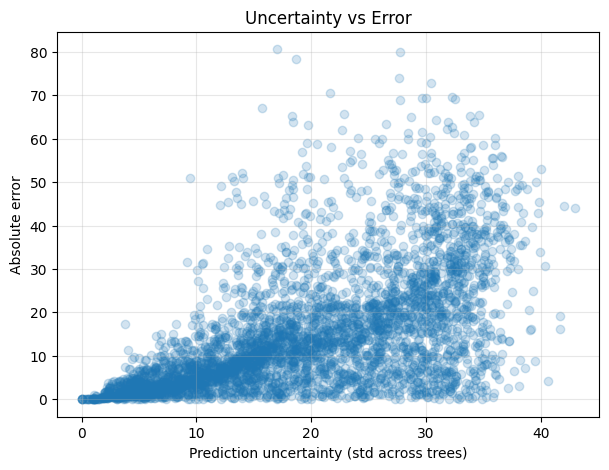

In [4]:
plot_uncertainty_vs_error(results_df)
plt.show()


In [5]:
uncertainty_bins = uncertainty_error_bins(results_df, bins=6)
uncertainty_bins


,uncertainty_bin,count,mean_uncertainty,mean_abs_error,median_abs_error,dangerous_rate,mean_overestimate
0,"(-0.001, 8.064]",679,4.990447,2.749205,1.970,0.418262,3.416620
1,"(8.064, 13.828]",678,10.975224,7.756608,6.095,0.352507,10.242092
2,"(13.828, 18.836]",678,16.306534,13.779454,11.440,0.379056,16.028599
3,"(18.836, 25.015]",678,21.844026,16.687035,14.010,0.455752,19.066537
4,"(25.015, 30.53]",678,27.830266,21.867832,19.945,0.480826,24.177270
5,"(30.53, 42.976]",679,33.461925,26.806244,27.340,0.405007,26.964727


In [6]:
print("Correlation between uncertainty and absolute error:")
print(results_df[["pred_std", "abs_error"]].corr())


Correlation between uncertainty and absolute error:
           pred_std  abs_error
pred_std    1.00000    0.58457
abs_error   0.58457    1.00000


## Save uncertainty results

The next notebook uses this table for maintenance-policy experiments.


In [7]:
results_df.to_csv(PROCESSED_DIR / "fd001_uncertainty_results.csv", index=False)
uncertainty_bins.to_csv(PROCESSED_DIR / "fd001_uncertainty_bins.csv", index=False)
print("Saved uncertainty outputs")


Saved uncertainty outputs
